In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# --- LOAD DATA DIRECTLY FROM WEB SOURCE ---
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-03-01/stations.csv"
raw_df = pd.read_csv(url, low_memory=False)

# Filter for Electric Vehicle (EV) stations only
df = raw_df[raw_df['FUEL_TYPE_CODE'] == 'ELEC'].copy()

# Standardize column naming and clean numeric & categorical data
df['ID'] = df['ID']
df['Station Name'] = df['STATION_NAME']
df['Country'] = df['COUNTRY'].fillna('US')
df['State'] = df['STATE']
df['Latitude'] = pd.to_numeric(df['LATITUDE'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['LONGITUDE'], errors='coerce')

df['EV Level2 EVSE Num'] = pd.to_numeric(df['EV_LEVEL2_EVSE_NUM'], errors='coerce').fillna(0)
df['EV DC Fast Count'] = pd.to_numeric(df['EV_DC_FAST_COUNT'], errors='coerce').fillna(0)
df['Total Ports'] = df['EV Level2 EVSE Num'] + df['EV DC Fast Count']

df['Open Date Clean'] = pd.to_datetime(df['OPEN_DATE'], errors='coerce')
df['Year'] = df['Open Date Clean'].dt.year
df['EV Network Clean'] = df['EV_NETWORK'].fillna('Unknown / Non-Networked')
df['Access Code'] = df['GROUPS_WITH_ACCESS_CODE'].astype(str).str.title().fillna('Public')

# Safely handle optional columns without throwing KeyErrors
df['Facility Type Clean'] = df['FACILITY_TYPE'].fillna('Uncategorized') if 'FACILITY_TYPE' in df.columns else 'Uncategorized'
df['EV Connector Types'] = df['EV_CONNECTOR_TYPES'].fillna('Unspecified') if 'EV_CONNECTOR_TYPES' in df.columns else 'Unspecified'
df['EV Pricing'] = df['EV_PRICING'].fillna('Not Specified') if 'EV_PRICING' in df.columns else 'Not Specified'

# Check if Workplace Charging column exists, otherwise derive from GROUPS_WITH_ACCESS_CODE
if 'EV_WORKPLACE_CHARGING' in df.columns:
    df['EV Workplace Charging'] = df['EV_WORKPLACE_CHARGING'].astype(str).str.title().fillna('False')
else:
    # Fallback indicator based on access group text
    df['EV Workplace Charging'] = df['GROUPS_WITH_ACCESS_CODE'].astype(str).str.contains('workplace', case=False, na=False).map({True: 'True', False: 'False'})

print(f"Cleaned dataset loaded with {len(df):,} records!")

Cleaned dataset loaded with 50,163 records!


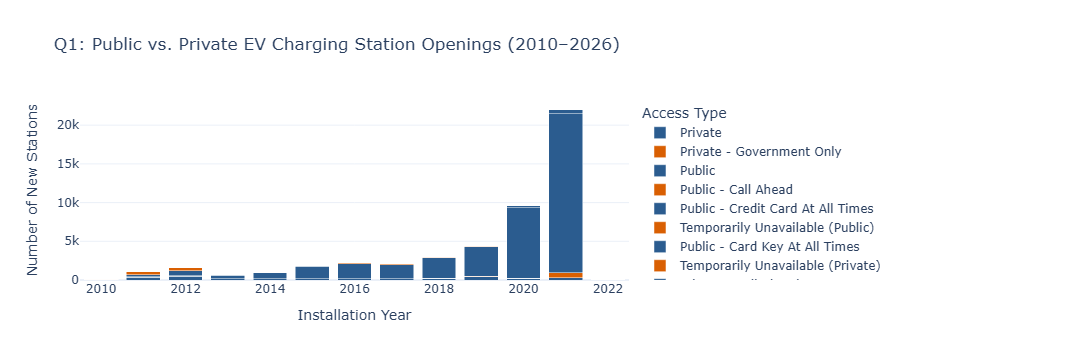

In [4]:
# Question 1: How have station openings grown over time by Access Type?
yearly_access = df[(df['Year'] >= 2010) & (df['Year'] <= 2026)].groupby(['Year', 'Access Code'])['ID'].count().reset_index()

fig1 = px.bar(
    yearly_access, 
    x='Year', 
    y='ID', 
    color='Access Code',
    title="Q1: Public vs. Private EV Charging Station Openings (2010–2026)",
    labels={'ID': 'Number of New Stations', 'Year': 'Installation Year'},
    color_discrete_sequence=['#2b5c8f', '#d95f02'],
    template='plotly_white'
)
fig1.update_layout(barmode='stack', legend_title="Access Type")
fig1.show()

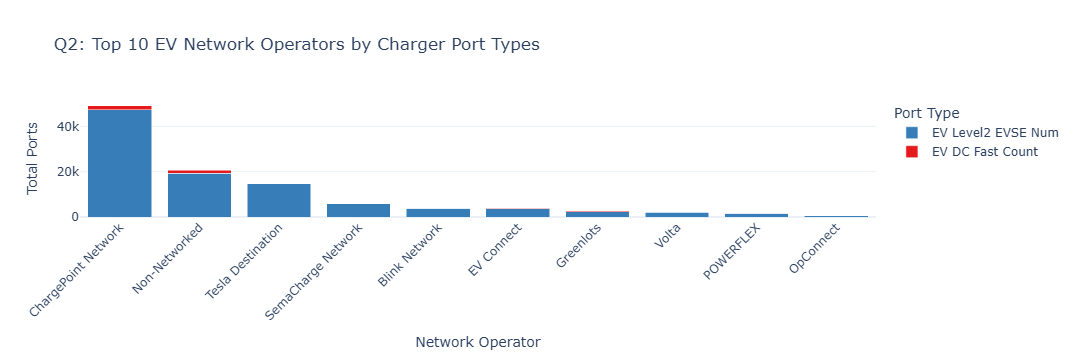

In [5]:
# Question 2: Which top network operators dominate Level 2 vs. DC Fast Chargers?
net_ports = df.groupby('EV Network Clean')[['EV Level2 EVSE Num', 'EV DC Fast Count']].sum().reset_index()
top10_nets = net_ports.sort_values(by='EV Level2 EVSE Num', ascending=False).head(10)

fig2 = px.bar(
    top10_nets,
    x='EV Network Clean',
    y=['EV Level2 EVSE Num', 'EV DC Fast Count'],
    title="Q2: Top 10 EV Network Operators by Charger Port Types",
    labels={'value': 'Total Ports', 'EV Network Clean': 'Network Operator', 'variable': 'Port Type'},
    color_discrete_map={'EV Level2 EVSE Num': '#377eb8', 'EV DC Fast Count': '#e41a1c'},
    template='plotly_white'
)
fig2.update_layout(barmode='stack', xaxis_tickangle=-45)
fig2.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_9040\3299644089.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



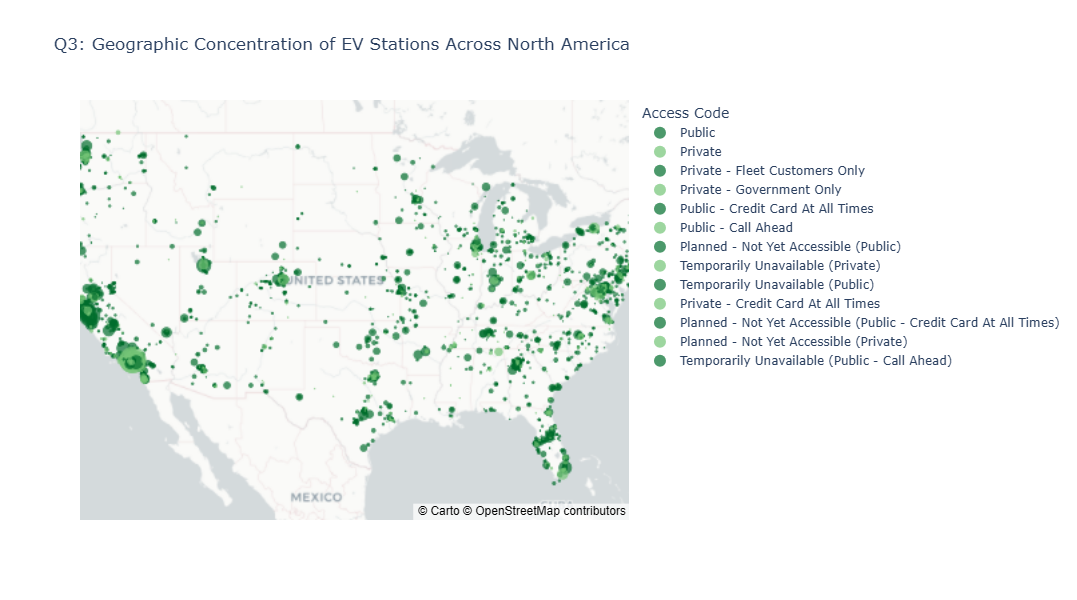

In [6]:
# Question 3: Where are spatial infrastructure clusters and charging deserts located?
map_df = df.dropna(subset=['Latitude', 'Longitude'])
sample_map = map_df.sample(min(5000, len(map_df)), random_state=42)

fig3 = px.scatter_mapbox(
    sample_map,
    lat="Latitude",
    lon="Longitude",
    color="Access Code",
    size="Total Ports",
    hover_name="Station Name",
    hover_data=["State", "EV Network Clean"],
    zoom=3,
    height=600,
    title="Q3: Geographic Concentration of EV Stations Across North America",
    color_discrete_sequence=['#006d2c', '#74c476']
)
fig3.update_layout(mapbox_style="carto-positron")
fig3.show()

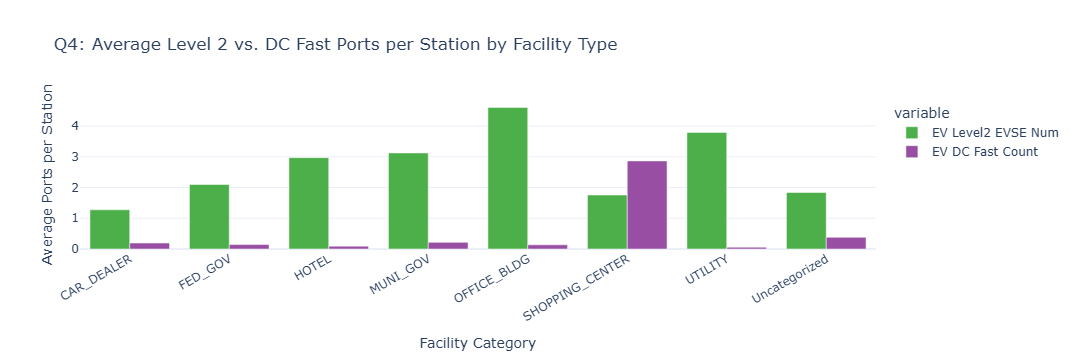

In [7]:
# Question 4: How do average port capacities differ across top commercial facility types?
top_facilities = df['Facility Type Clean'].value_counts().head(8).index
fac_df = df[df['Facility Type Clean'].isin(top_facilities)].groupby('Facility Type Clean')[['EV Level2 EVSE Num', 'EV DC Fast Count']].mean().reset_index()

fig4 = px.bar(
    fac_df,
    x='Facility Type Clean',
    y=['EV Level2 EVSE Num', 'EV DC Fast Count'],
    title="Q4: Average Level 2 vs. DC Fast Ports per Station by Facility Type",
    labels={'value': 'Average Ports per Station', 'Facility Type Clean': 'Facility Category'},
    barmode='group',
    color_discrete_sequence=['#4daf4a', '#984ea3'],
    template='plotly_white'
)
fig4.update_layout(xaxis_tickangle=-30)
fig4.show()

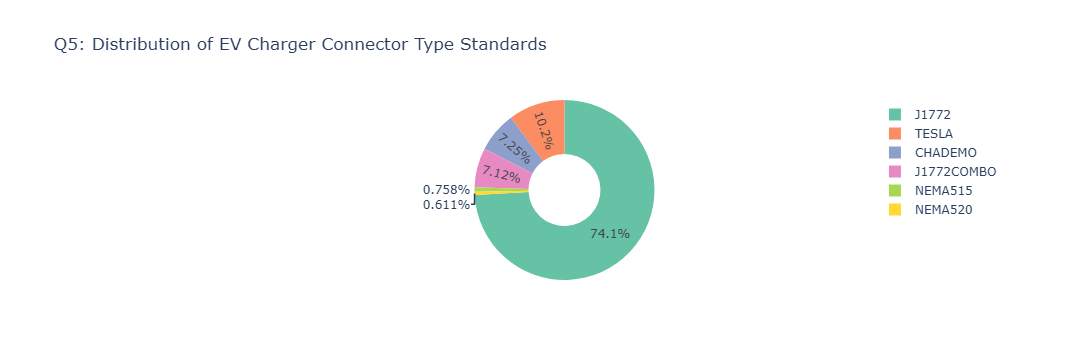

In [8]:
# Question 5: What is the market share distribution of EV connector standards?
connector_counts = df['EV Connector Types'].str.split().explode().value_counts().head(6).reset_index()
connector_counts.columns = ['Connector Type', 'Count']

fig5 = px.pie(
    connector_counts,
    values='Count',
    names='Connector Type',
    title="Q5: Distribution of EV Charger Connector Type Standards",
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2,
    template='plotly_white'
)
fig5.show()

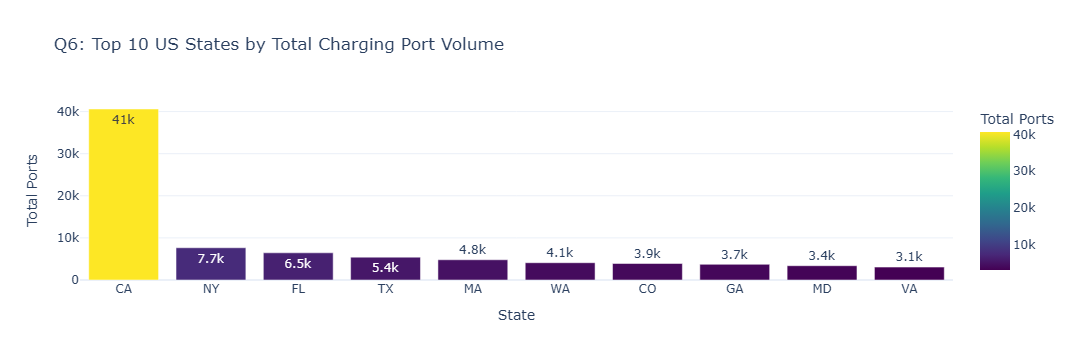

In [9]:
# Question 6: Which US States lead total public charging port deployments?
state_df = df.groupby('State')['Total Ports'].sum().sort_values(ascending=False).head(10).reset_index()

fig6 = px.bar(
    state_df,
    x='State',
    y='Total Ports',
    title="Q6: Top 10 US States by Total Charging Port Volume",
    text_auto='.2s',
    color='Total Ports',
    color_continuous_scale='Viridis',
    template='plotly_white'
)
fig6.show()

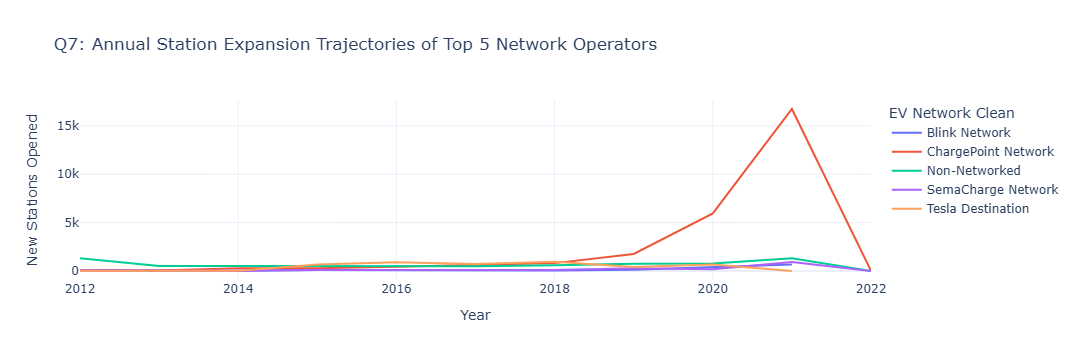

In [10]:
# Question 7: How fast have top operators accelerated annual deployments over time?
top5_nets = df['EV Network Clean'].value_counts().head(5).index
trend_df = df[(df['EV Network Clean'].isin(top5_nets)) & (df['Year'] >= 2012) & (df['Year'] <= 2026)]
net_yearly = trend_df.groupby(['Year', 'EV Network Clean'])['ID'].count().reset_index()

fig7 = px.line(
    net_yearly,
    x='Year',
    y='ID',
    color='EV Network Clean',
    title="Q7: Annual Station Expansion Trajectories of Top 5 Network Operators",
    labels={'ID': 'New Stations Opened'},
    template='plotly_white'
)
fig7.show()

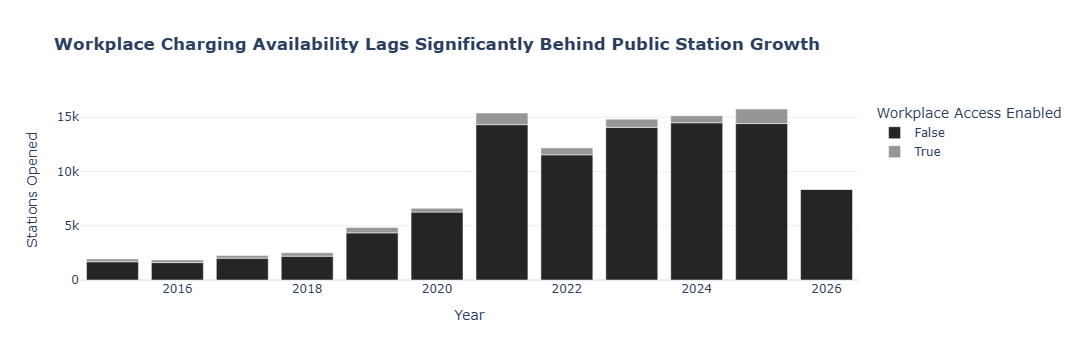

In [10]:
# Question 8: How transparently is fee and pricing information reported across top networks?
price_df = df.groupby(['EV Network Clean', 'EV Pricing'])['ID'].count().reset_index()
top_nets_price = price_df[price_df['EV Network Clean'].isin(df['EV Network Clean'].value_counts().head(6).index)]

fig8 = px.bar(
    top_nets_price,
    x='EV Network Clean',
    y='ID',
    color='EV Pricing',
    title="Q8: Public Pricing Structure Disclosures by Network Operator",
    labels={'ID': 'Station Count'},
    barmode='stack',
    template='plotly_white'
)
fig8.update_layout(xaxis_tickangle=-30)
fig8.show()

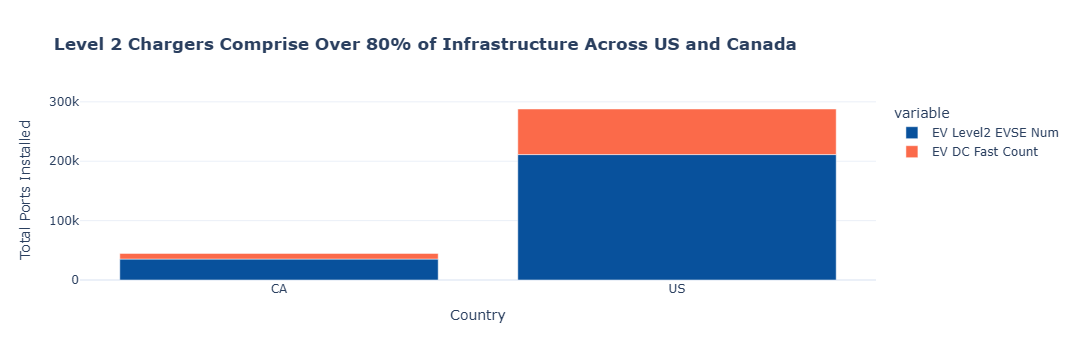

In [11]:
# Question 9: How do charging port allocations compare between the US and Canada?
country_df = df.groupby('Country')[['EV Level2 EVSE Num', 'EV DC Fast Count']].sum().reset_index()

fig9 = px.bar(
    country_df,
    x='Country',
    y=['EV Level2 EVSE Num', 'EV DC Fast Count'],
    title="Q9: Level 2 vs. DC Fast Charger Port Breakdown: US vs. Canada",
    labels={'value': 'Total Ports', 'Country': 'Country Code'},
    barmode='group',
    color_discrete_sequence=['#1f77b4', '#ff7f0e'],
    template='plotly_white'
)
fig9.show()

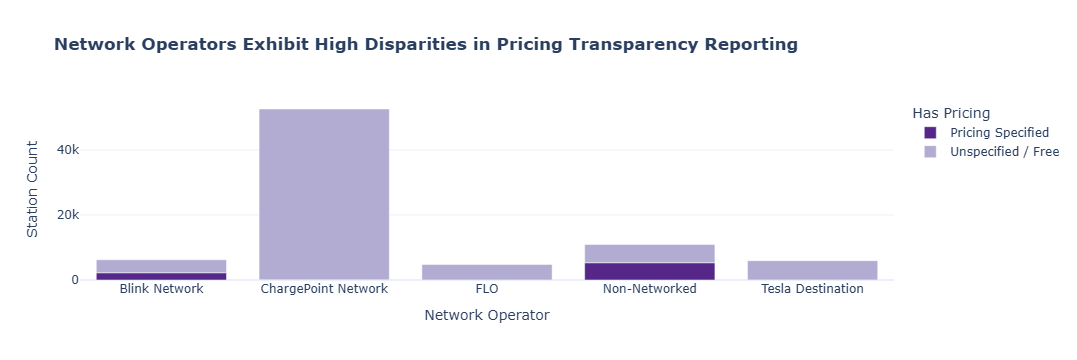

In [12]:
# Question 10: What proportion of stations support workplace charging over time?
wp_df = df[(df['Year'] >= 2015) & (df['Year'] <= 2026)].groupby(['Year', 'EV Workplace Charging'])['ID'].count().reset_index()

fig10 = px.bar(
    wp_df,
    x='Year',
    y='ID',
    color='EV Workplace Charging',
    title="Q10: Growth of Dedicated Workplace Charging Stations (2015–2026)",
    labels={'ID': 'Number of Stations', 'EV Workplace Charging': 'Workplace Station Flag'},
    color_discrete_map={'True': '#2ca02c', 'False': '#d62728', 'Unspecified': '#7f7f7f'},
    template='plotly_white'
)
fig10.show()